# Constraint Satisfaction Problem : Graph coloring


## Create Data

We can create a planar graph with $n$ vertices by randomly placing $n$ points in 2-dimensional Euclidean space and then performing a [Delaunay triangulation](https://en.wikipedia.org/wiki/Delaunay_triangulation).

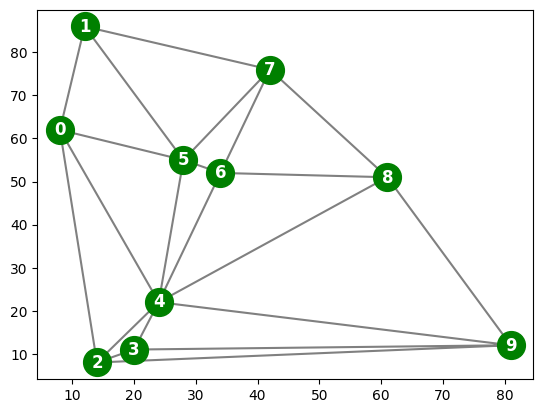

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

np.random.seed(1111)

# create points and sort them by 
n = 10
points = np.random.randint(100, size=(n, 2))
o = np.argsort(points[:,0])
points = points[o,:]


# triangulate
tri = Delaunay(points)


# plot
plt.triplot(points[:,0], points[:,1], tri.simplices, color = "gray")
plt.plot(points[:,0], points[:,1], 'o', color = "green", markersize = 20)

for i in range(len(points)):
       plt.annotate(i, points[i,:], 
        color='white', fontsize="large", weight='heavy',
        horizontalalignment='center', verticalalignment='center')

plt.show()

The triangulation can be converted into a list with an array of neighbor vertex indices for each point (see man page for [scipy.spatial.Delaunay](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.Delaunay.html)). 

In [102]:
(indptr, indices) = tri.vertex_neighbor_vertices

neighbors = []

for k in range(len(indptr)-1):
    neighbors.append(np.sort(indices[indptr[k]:indptr[k+1]]))
    
neighbors

[array([1, 2, 4, 5], dtype=int32),
 array([0, 5, 7], dtype=int32),
 array([0, 3, 4, 9], dtype=int32),
 array([2, 4, 9], dtype=int32),
 array([0, 2, 3, 5, 6, 8, 9], dtype=int32),
 array([0, 1, 4, 6, 7], dtype=int32),
 array([4, 5, 7, 8], dtype=int32),
 array([1, 5, 6, 8], dtype=int32),
 array([4, 6, 7, 9], dtype=int32),
 array([2, 3, 4, 8], dtype=int32)]

The first row are the indices for the points neighboring point 0.

## Define CSP

The problem is defined as a dictionary with variable names, a dictionary with domain values for each variable and a set of binary  not-equal constraints (tuples of variables that are not allowed to have the same value).  

In [103]:
variables = [str(var) for var in range(n)]

domain = ['red', 'blue', 'green', 'orange']
#domain = ['red', 'blue', 'green']
domains = {}
for v in variables: 
    domains[v] = domain

# create binary constraints
constraints = {}
for i in range(len(neighbors)):
    for j in neighbors[i]:
        if(i<j): constraints[tuple([str(i), str(j)])] = True
constraints = constraints.keys()

csp = {'variables': variables, 'domains': domains, 'constraints': constraints, }
csp

{'variables': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
 'domains': {'0': ['red', 'blue', 'green', 'orange'],
  '1': ['red', 'blue', 'green', 'orange'],
  '2': ['red', 'blue', 'green', 'orange'],
  '3': ['red', 'blue', 'green', 'orange'],
  '4': ['red', 'blue', 'green', 'orange'],
  '5': ['red', 'blue', 'green', 'orange'],
  '6': ['red', 'blue', 'green', 'orange'],
  '7': ['red', 'blue', 'green', 'orange'],
  '8': ['red', 'blue', 'green', 'orange'],
  '9': ['red', 'blue', 'green', 'orange']},
 'constraints': dict_keys([('0', '1'), ('0', '2'), ('0', '4'), ('0', '5'), ('1', '5'), ('1', '7'), ('2', '3'), ('2', '4'), ('2', '9'), ('3', '4'), ('3', '9'), ('4', '5'), ('4', '6'), ('4', '8'), ('4', '9'), ('5', '6'), ('5', '7'), ('6', '7'), ('6', '8'), ('7', '8'), ('8', '9')])}

## Check Completeness and Consistency

`assignment` is a dictionary. Assigned variables have an entry with the variable name as the key. `{}` is therefore the empty assignment.

In [104]:
def complete(assignment, csp):
    return(all([v in assignment.keys() for v in csp['variables']])) 

print("complete({}, csp) =", complete({}, csp))

print("complete({...complete list...}, csp) =", 
      complete({'0': 'red', '1': 'red', '2': 'red', '3': 'red', '4': 'red', 
          '5': 'red', '6': 'red', '7': 'red', '8': 'red', '9': 'red'}, csp))

complete({}, csp) = False
complete({...complete list...}, csp) = True


In [105]:
def consistent(assignment, csp):
    for constr in csp['constraints']:
        if(constr[0] in assignment.keys() and constr[1] in assignment.keys()):
            if assignment[constr[0]] == assignment[constr[1]]: return(False)
        
    return(True)
        
print("consistent({}, csp) =", consistent({}, csp))
print("consistent({'0': 'red', '1': 'red', '2': 'blue'}, csp) =", 
      consistent({'0': 'red', '1': 'red', '2': 'blue'}, csp))

consistent({}, csp) = True
consistent({'0': 'red', '1': 'red', '2': 'blue'}, csp) = False


## Implement Simple Backtracking Search

In [106]:
# TODO: implement variable ordering. Choose variable with the minimum-remaining-values (MRV)
def select_unassigned_var(assignment, csp):
    if(complete(assignment, csp)): return(None)
    
    return(csp['variables'][np.where([not v in assignment.keys() for v in csp['variables']])[0][0]])

print("select_unassigned_var({'0': 'red', '1': 'blue'}, csp) =", 
     select_unassigned_var({'0': 'red', '1': 'blue'}, csp))

select_unassigned_var({'0': 'red', '1': 'blue'}, csp) = 2


In [107]:
# I use a global variable to turn on verbose mode in the recursion
#VERBOSE = True
VERBOSE = False
COUNT = 0

# returns None for failure
def backtrack_search(csp):
    global COUNT
    COUNT = 0
    
    assignment = backtrack({}, csp)
    
    print(f"Checked nodes: {COUNT}")
    
    return assignment

def backtrack(assignment, csp):
    global VERBOSE, COUNT
    
    COUNT += 1
    
    if complete(assignment, csp): 
        return assignment
    
    var = select_unassigned_var(assignment, csp)
    
    # TODO: implement value ordering. Use the least-constraining-vaue heuristic. 
    # for val in order_domain(assignment, var, csp)
    for val in csp['domains'][var]:
        assignment[var] = val
        
        if VERBOSE: print(f"Checking: {assignment}")
        
        if consistent(assignment, csp):
            
            #TODO: add inference for early failing (forward checking, )
            # if inference_fails(assignment, csp): return(None)
            result = backtrack(assignment, csp)
            if not result is None:
                    return(result)
                
        del assignment[var]
        
    if verbose: print(f"Backtracking")
    return(None) 

## Run Backtracking Search on the Random Problem

In [108]:
%timeit -n1 -r1 display(backtrack_search(csp))

Checked nodes: 11


{'0': 'red',
 '1': 'blue',
 '2': 'blue',
 '3': 'red',
 '4': 'green',
 '5': 'orange',
 '6': 'red',
 '7': 'green',
 '8': 'blue',
 '9': 'orange'}

2.99 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


Plot the resulting coloring

In [109]:
res = backtrack_search(csp)


Checked nodes: 11


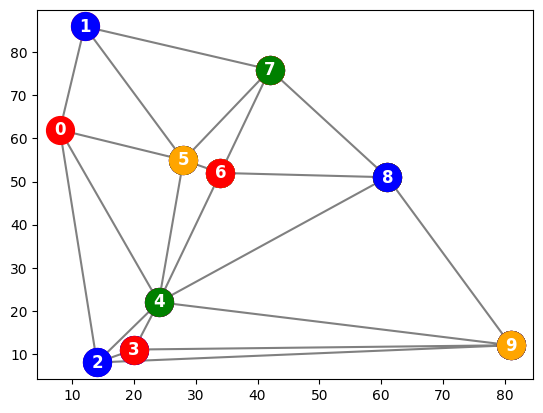

In [110]:
plt.triplot(points[:,0], points[:,1], tri.simplices, color = "gray")

for i in range(len(points)):
        plt.plot(points[i:,0], points[i:,1], 'o', color = list(res.values())[i], markersize = 20)
        plt.annotate(i, points[i,:], 
        color='white', fontsize="large", weight='heavy',
        horizontalalignment='center', verticalalignment='center')

plt.show()

## Assignment

Implement the following graph coloring algorithms:

* Add variable and value ordering to the implementation.
* Add forward checking to the implementation.
* Implement hill climbing local search with the min-conflicts heuristic.

Try to color graphs of several sizes with 3 and 4 colors. For each $n$, generate several random instances, and try to make n as large as you can manage. On average, how many constraints (edges) do your map coloring instances have for each $n$? Report the performance of each search algorithm as a function of $n$. For both variants of backtracking search, you can characterize performance in terms of the number of variable assignments attempted. For hill climbing search, report the number of uphill moves and random restarts required in order to reach a solution. Of course, you can also report raw running times as a function of $n$.

MRV — Minimum Remaining Values (Chọn biến)

In [111]:
def select_unassigned_var(assignment, csp):
    """
    Heuristic MRV (Minimum Remaining Values)
    → Chọn biến chưa gán có số lượng giá trị hợp lệ (màu có thể dùng) ít nhất.
    """
    unassigned_vars = [v for v in csp['variables'] if v not in assignment]

    # Nếu tất cả biến đã gán thì trả None
    if not unassigned_vars:
        return None

    def num_valid_values(var):
        """Đếm số màu hợp lệ còn lại cho biến var."""
        count = 0
        for color in csp['domains'][var]:
            assignment[var] = color
            if consistent(assignment, csp):
                count += 1
            del assignment[var]
        return count

    # Trả về biến có số lượng giá trị hợp lệ nhỏ nhất
    return min(unassigned_vars, key=num_valid_values)


LCV — Least Constraining Value (Chọn giá trị)

In [112]:
def order_domain_values(var, assignment, csp):
    """
    Heuristic LCV (Least Constraining Value)
    → Trả về danh sách các màu được sắp xếp sao cho ít gây xung đột nhất.
    """
    # Tìm danh sách hàng xóm (neighbor) của biến var
    neighbors = [v2 if v1 == var else v1
                 for (v1, v2) in csp['constraints']
                 if var in (v1, v2)]

    def count_conflicts(value):
        """Đếm số màu bị loại khỏi các hàng xóm nếu var chọn màu value."""
        conflicts = 0
        for nb in neighbors:
            if nb not in assignment:
                for nb_color in csp['domains'][nb]:
                    if nb_color == value:
                        conflicts += 1
        return conflicts

    # Trả về danh sách màu được sắp xếp theo số xung đột tăng dần
    return sorted(csp['domains'][var], key=count_conflicts)


Forward checking (Kiểm tra tiến bộ)

In [113]:
def forward_check(var, value, assignment, csp, domains_copy):
    """
    Kiểm tra và cập nhật domain của các biến chưa gán sau khi gán var=value.
    Nếu phát hiện biến nào không còn giá trị hợp lệ thì trả về False.
    """
    for (x, y) in csp['constraints']:
        # Nếu var liên quan đến constraint (x, y)
        if var == x and y not in assignment:
            if value in domains_copy[y]:
                domains_copy[y].remove(value)
                if len(domains_copy[y]) == 0:
                    return False
        elif var == y and x not in assignment:
            if value in domains_copy[x]:
                domains_copy[x].remove(value)
                if len(domains_copy[x]) == 0:
                    return False
    return True


Cập nhật hàm backtrack

In [114]:
def backtrack_search(csp):
    global COUNT
    COUNT = 0
    
    assignment = backtrack({}, csp)
    
    print(f"Checked nodes: {COUNT}")
    
    return assignment


def backtrack(assignment, csp):
    global VERBOSE, COUNT
    COUNT += 1

    # Nếu tất cả biến đã được gán thì trả về nghiệm
    if complete(assignment, csp):
        return assignment

    # Chọn biến chưa gán theo MRV
    var = select_unassigned_var(assignment, csp)

    # Duyệt giá trị theo LCV
    for val in order_domain_values(var, assignment, csp):
        assignment[var] = val

        if VERBOSE:
            print(f"→ Gán {var} = {val}")

        if consistent(assignment, csp):
            # ✅ Sao chép domain hiện tại để thực hiện forward checking
            new_domains = {v: list(csp['domains'][v]) for v in csp['domains']}

            # ✅ Thực hiện forward checking
            valid = True
            for (x, y) in csp['constraints']:
                if var == x and y not in assignment:
                    if val in new_domains[y]:
                        new_domains[y].remove(val)
                        if len(new_domains[y]) == 0:
                            valid = False
                            break
                elif var == y and x not in assignment:
                    if val in new_domains[x]:
                        new_domains[x].remove(val)
                        if len(new_domains[x]) == 0:
                            valid = False
                            break

            if valid:
                # ✅ Tạo CSP mới với domain đã rút gọn
                new_csp = {
                    'variables': csp['variables'],
                    'domains': new_domains,
                    'constraints': csp['constraints']
                }

                # ✅ Gọi đệ quy với domain rút gọn
                result = backtrack(assignment, new_csp)
                if result is not None:
                    return result

        # Xóa gán nếu thất bại
        del assignment[var]

    return None


In [115]:
res = backtrack_search(csp)
print(res)


Checked nodes: 11
{'0': 'red', '1': 'blue', '5': 'green', '4': 'blue', '2': 'green', '3': 'red', '9': 'orange', '6': 'orange', '7': 'red', '8': 'green'}


Hàm đếm xung đột

In [116]:
def count_conflicts(var, value, assignment, csp):
    """Đếm số đỉnh kề có cùng màu"""
    count = 0
    for (x, y) in csp['constraints']:
        if var == x and y in assignment and assignment[y] == value:
            count += 1
        elif var == y and x in assignment and assignment[x] == value:
            count += 1
    return count


Thuật toán Hill-Climbing với Min-Conflicts

In [117]:
import random
import time

def min_conflicts(csp, max_steps=1000, max_restarts=10):
    variables = csp['variables']
    domains = csp['domains']
    constraints = csp['constraints']
    
    restarts = 0
    uphill_moves = 0
    start_time = time.time()
    
    # Hàm tạo gán ngẫu nhiên ban đầu
    def random_assignment():
        return {v: random.choice(domains[v]) for v in variables}
    
    # Lặp qua nhiều lần restart
    assignment = random_assignment()
    
    for restart in range(max_restarts):
        restarts = restart
        for step in range(max_steps):
            # Tìm các biến đang gây xung đột
            conflicted_vars = []
            for (x, y) in constraints:
                if assignment[x] == assignment[y]:
                    conflicted_vars.extend([x, y])
            conflicted_vars = list(set(conflicted_vars))
            
            # Nếu không còn xung đột → thành công
            if len(conflicted_vars) == 0:
                elapsed = time.time() - start_time
                print(f"✅ Found solution in {step} steps, {restart} restarts, {uphill_moves} moves, time: {elapsed:.3f}s")
                return assignment
            
            # Chọn 1 biến gây xung đột ngẫu nhiên
            var = random.choice(conflicted_vars)
            
            # Tính số xung đột cho từng màu trong domain
            conflicts_per_value = {}
            for val in domains[var]:
                conflicts_per_value[val] = count_conflicts(var, val, assignment, csp)
            
            # Chọn màu ít xung đột nhất (min-conflicts)
            min_conf = min(conflicts_per_value.values())
            best_values = [v for v in domains[var] if conflicts_per_value[v] == min_conf]
            
            # Nếu có nhiều màu tốt ngang nhau → chọn ngẫu nhiên
            new_value = random.choice(best_values)
            
            # Nếu có cải thiện thì coi là “uphill move”
            if new_value != assignment[var]:
                uphill_moves += 1
            
            # Cập nhật
            assignment[var] = new_value
        
        # Nếu quá max_steps mà chưa xong → restart lại
        assignment = random_assignment()
    
    print("❌ Không tìm được nghiệm trong giới hạn restart.")
    return None


In [118]:
res_hill = min_conflicts(csp, max_steps=2000, max_restarts=20)
print(res_hill)


✅ Found solution in 2 steps, 0 restarts, 2 moves, time: 0.000s
{'0': 'blue', '1': 'red', '2': 'green', '3': 'blue', '4': 'red', '5': 'green', '6': 'blue', '7': 'orange', '8': 'green', '9': 'orange'}


    n  colors  constraints  bt_assigns   bt_time  adv_assigns  adv_time  \
0  10       3           13         292  0.000000           10  0.000000   
1  20       3           63         346  0.000000            4  0.000000   
2  30       3          158         148  0.003129            5  0.000000   
3  40       3          290         859  0.023008            4  0.001044   
4  50       3          506         427  0.021208            4  0.006574   
5  10       4           13          11  0.000000           11  0.000000   
6  20       4           62       14533  0.159930            7  0.000000   
7  30       4          151        4169  0.105071            7  0.001333   
8  40       4          234        3365  0.115819            7  0.000000   
9  50       4          396        2341  0.114069            7  0.001000   

   hill_steps  hill_restarts  hill_moves  hill_time  
0        1999             10          17   0.473577  
1        1999             10        2201   2.079256  
2        199

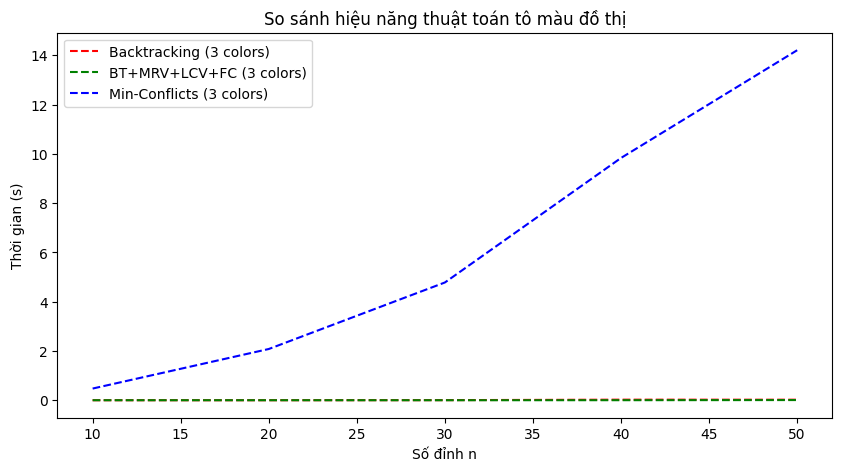

In [119]:
import random, time, numpy as np
import matplotlib.pyplot as plt

# ======= TẠO CSP NGẪU NHIÊN =======
def generate_random_graph_csp(n, colors=['red','green','blue']):
    points = np.random.rand(n, 2)
    constraints = set()
    for i in range(n):
        for j in range(i+1, n):
            if np.linalg.norm(points[i] - points[j]) < 0.4:  # khoảng cách < 0.4 => có cạnh
                constraints.add((str(i), str(j)))
    variables = [str(i) for i in range(n)]
    domains = {v: colors[:] for v in variables}
    return {'variables': variables, 'domains': domains, 'constraints': list(constraints)}

# ======= CÁC HÀM PHỤ =======
def complete(assignment, csp): 
    return len(assignment) == len(csp['variables'])

def consistent(assignment, csp):
    for (a,b) in csp['constraints']:
        if a in assignment and b in assignment and assignment[a] == assignment[b]:
            return False
    return True

# ======= MRV =======
def select_unassigned_var(assignment, csp):
    unassigned = [v for v in csp['variables'] if v not in assignment]
    if not unassigned: return None
    mrv = min(unassigned, key=lambda var: len(csp['domains'][var]))
    return mrv

# ======= LCV =======
def order_domain_values(var, assignment, csp):
    def count_conflicts(value):
        count = 0
        for (a,b) in csp['constraints']:
            if a == var and b not in assignment:
                count += sum(value == val for val in csp['domains'][b])
            elif b == var and a not in assignment:
                count += sum(value == val for val in csp['domains'][a])
        return count
    return sorted(csp['domains'][var], key=count_conflicts)

# ======= Forward Checking =======
def forward_check(var, value, assignment, csp):
    saved_domains = {v: list(csp['domains'][v]) for v in csp['variables']}
    for (a,b) in csp['constraints']:
        other = None
        if a == var: other = b
        elif b == var: other = a
        if other and other not in assignment:
            if value in csp['domains'][other]:
                csp['domains'][other].remove(value)
                if not csp['domains'][other]:
                    csp['domains'].update(saved_domains)
                    return False
    return True

# ======= Backtracking Search =======
def backtrack_search(csp, use_mrv=False, use_lcv=False, use_fc=False):
    global COUNT
    COUNT = 0
    start = time.time()
    result = backtrack({}, csp, use_mrv, use_lcv, use_fc)
    runtime = time.time() - start
    return result, COUNT, runtime

def backtrack(assignment, csp, use_mrv, use_lcv, use_fc):
    global COUNT
    COUNT += 1
    if complete(assignment, csp): return assignment

    var = select_unassigned_var(assignment, csp) if use_mrv else \
          [v for v in csp['variables'] if v not in assignment][0]
    values = order_domain_values(var, assignment, csp) if use_lcv else csp['domains'][var]

    for val in values:
        assignment[var] = val
        if consistent(assignment, csp):
            if use_fc:
                if not forward_check(var, val, assignment, csp):
                    del assignment[var]
                    continue
            result = backtrack(assignment, csp, use_mrv, use_lcv, use_fc)
            if result: return result
        del assignment[var]
    return None

# ======= Hill Climbing (Min-Conflicts) =======
def min_conflicts(csp, max_steps=2000, max_restarts=10):
    def random_assignment():
        return {v: random.choice(csp['domains'][v]) for v in csp['variables']}

    def conflicted_vars(assignment):
        return [v for v in csp['variables'] if any(
            (v == a and assignment[a]==assignment[b]) or (v == b and assignment[a]==assignment[b])
            for (a,b) in csp['constraints']
        )]

    best = None
    restarts = 0
    moves = 0
    start = time.time()

    for _ in range(max_restarts):
        assignment = random_assignment()
        for step in range(max_steps):
            conflicted = conflicted_vars(assignment)
            if not conflicted:
                return assignment, step, restarts, moves, time.time() - start
            var = random.choice(conflicted)
            values = csp['domains'][var]
            conflicts = [sum(
                (var == a and val == assignment[b]) or (var == b and val == assignment[a])
                for (a,b) in csp['constraints']
            ) for val in values]
            min_conf = min(conflicts)
            best_val = random.choice([values[i] for i in range(len(values)) if conflicts[i]==min_conf])
            if assignment[var] != best_val:
                moves += 1
            assignment[var] = best_val
        restarts += 1
    return None, step, restarts, moves, time.time() - start

# ======= CHẠY THỬ NGHIỆM =======
ns = [10, 20, 30, 40, 50]
colorsets = [['red','green','blue'], ['red','green','blue','orange']]

results = []

for colors in colorsets:
    for n in ns:
        csp = generate_random_graph_csp(n, colors)
        avg_constraints = len(csp['constraints'])

        # Backtracking cơ bản
        _, count_bt, t_bt = backtrack_search(csp)
        # Backtracking + MRV + LCV + FC
        _, count_adv, t_adv = backtrack_search(csp, True, True, True)
        # Hill-Climbing
        res, steps, restarts, moves, t_hill = min_conflicts(csp)

        results.append({
            'n': n,
            'colors': len(colors),
            'constraints': avg_constraints,
            'bt_assigns': count_bt,
            'bt_time': t_bt,
            'adv_assigns': count_adv,
            'adv_time': t_adv,
            'hill_steps': steps,
            'hill_restarts': restarts,
            'hill_moves': moves,
            'hill_time': t_hill
        })

# ======= HIỂN THỊ KẾT QUẢ =======
import pandas as pd
df = pd.DataFrame(results)
print(df)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10,5))
plt.plot(df[df['colors']==3]['n'], df[df['colors']==3]['bt_time'], 'r--', label='Backtracking (3 colors)')
plt.plot(df[df['colors']==3]['n'], df[df['colors']==3]['adv_time'], 'g--', label='BT+MRV+LCV+FC (3 colors)')
plt.plot(df[df['colors']==3]['n'], df[df['colors']==3]['hill_time'], 'b--', label='Min-Conflicts (3 colors)')
plt.xlabel("Số đỉnh n")
plt.ylabel("Thời gian (s)")
plt.title("So sánh hiệu năng thuật toán tô màu đồ thị")
plt.legend()
plt.show()
